In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import platform
import os

import sklearn
sklearn.set_config(display="text")

# 1. 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac OS
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumBarunGothic')

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [5]:
base_path = r"C:\kdt_0900_osh\ml\resource\datasets"
file_name = r"fish.csv"

file_path = os.path.join(base_path, file_name)

df = pd.read_csv(file_path)
df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...
154,Smelt,12.2,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,14.3,15.2,2.8728,2.0672


In [6]:
df["Species"].unique()

<StringArray>
['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt']
Length: 7, dtype: str

### fish 종류
    Bream: 도미류
    Roach: 잉어과 담수어
    Whitefish: 송어
    Parkki: 청돔
    Perch: 농어
    Pike: 강꼬치고기
    Smelt: 빙어

### fish 컬럼 설명
| 컬럼명 (Column) | 설명 (Description) | 단위 (Unit) |
| :--- | :--- | :--- |
| **Species** | 물고기의 종류 (예: Bream, Smelt 등) | 분류 (텍스트) |
| **Weight** | 물고기의 무게 | 그램 (g) |
| **Length** | 물고기의 길이 | 센티미터 (cm) |
| **Diagonal** | 물고기의 대각선 길이 | 센티미터 (cm) |
| **Height** | 물고기의 최대 높이 | 센티미터 (cm) |
| **Width** | 물고기의 최대 너비 | 센티미터 (cm) |

In [7]:
df["Species"].value_counts()

Species
Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   159 non-null    str    
 1   Weight    159 non-null    float64
 2   Length    159 non-null    float64
 3   Diagonal  159 non-null    float64
 4   Height    159 non-null    float64
 5   Width     159 non-null    float64
dtypes: float64(5), str(1)
memory usage: 7.6 KB


In [12]:
df.describe()

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


## 분류 문제 지도학습 목표
- 생선의 길이와 무게 만으로 생선의 종류를 분류
- 도미, 빙어

[25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
[242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]


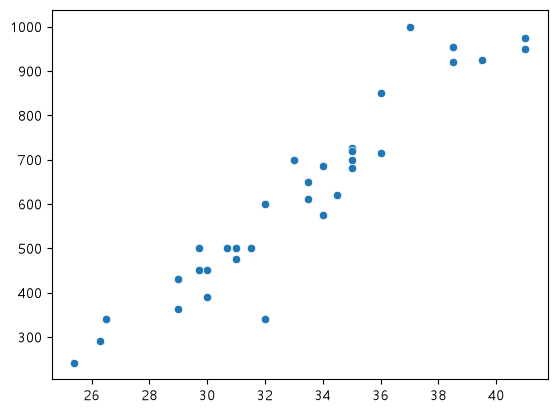

In [22]:
# bream: 도미(총 35개 데이터)
bream_length = df[df["Species"] == "Bream"]["Length"].to_list()
bream_weight = df[df["Species"] == "Bream"]["Weight"].to_list()

print(bream_length)
print(bream_weight)

# 선형적으로 증가하는 데이터
sns.scatterplot(x=bream_length, y=bream_weight)
plt.show()

[9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
[6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]


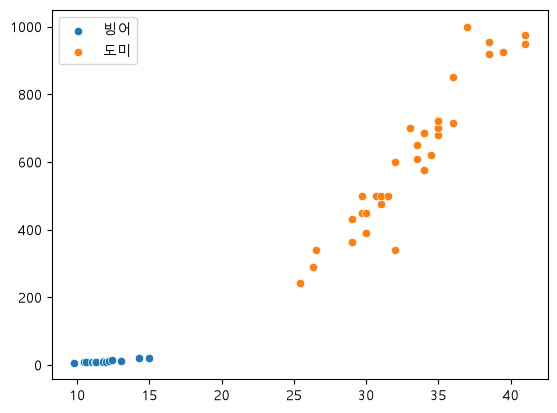

In [25]:
# smelt: 빙어(총 14개 데이터)
smelt_length = df[df["Species"] == "Smelt"]["Length"].to_list()
smelt_weight = df[df["Species"] == "Smelt"]["Weight"].to_list()

print(smelt_length)
print(smelt_weight)

# 선형적으로 증가하는 데이터
sns.scatterplot(x=smelt_length, y=smelt_weight)
sns.scatterplot(x=bream_length, y=bream_weight)
plt.legend(["빙어", "도미"])
plt.show()

In [27]:
# .isin() : db의 where~in~ 절과 같은 역할
fish_df = df[df["Species"].isin(["Bream", "Smelt"])]
fish_df

,Species,Weight,Length,Diagonal,Height,Width
0,Bream,242.0,25.4,30.0,11.5200,4.0200
1,Bream,290.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,26.5,31.1,12.3778,4.6961
3,Bream,363.0,29.0,33.5,12.7300,4.4555
4,Bream,430.0,29.0,34.0,12.4440,5.1340
5,Bream,450.0,29.7,34.7,13.6024,4.9274
6,Bream,500.0,29.7,34.5,14.1795,5.2785
7,Bream,390.0,30.0,35.0,12.6700,4.6900
8,Bream,450.0,30.0,35.1,14.0049,4.8438
9,Bream,500.0,30.7,36.2,14.2266,4.9594


## 분류형 데이터 인코딩 : 분류형 데이터를 수치형 데이터로 바꾸는 작업

In [28]:
# fish_df["Species"].map(lambda species: {"Bream":0, "Smelt":1}[species])
# 참조형(lambda 생략 가능)
fish_df["Species"] = fish_df["Species"].map({"Bream":0, "Smelt":1})

In [29]:
fish_df.head()

,Species,Weight,Length,Diagonal,Height,Width
0,0,242.0,25.4,30.0,11.5200,4.0200
1,0,290.0,26.3,31.2,12.4800,4.3056
2,0,340.0,26.5,31.1,12.3778,4.6961
3,0,363.0,29.0,33.5,12.7300,4.4555
4,0,430.0,29.0,34.0,12.4440,5.1340


## 1단계. 데이터 준비(탐색)

In [30]:
fish_df.info()

<class 'pandas.DataFrame'>
Index: 49 entries, 0 to 158
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Species   49 non-null     int64  
 1   Weight    49 non-null     float64
 2   Length    49 non-null     float64
 3   Diagonal  49 non-null     float64
 4   Height    49 non-null     float64
 5   Width     49 non-null     float64
dtypes: float64(5), int64(1)
memory usage: 2.7 KB


In [31]:
fish_df.describe()

,Species,Weight,Length,Diagonal,Height,Width
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,0.285714,444.500000,27.055102,31.120408,11.476400,4.259751
std,0.456435,328.143233,10.242804,12.097296,6.150976,1.967686
min,0.000000,6.700000,9.800000,10.800000,1.728400,1.047600
25%,0.000000,19.700000,14.300000,15.200000,2.872800,1.879200
50%,0.000000,500.000000,31.000000,36.200000,14.179500,5.072800
75%,1.000000,700.000000,34.500000,39.700000,15.633000,5.589000
max,1.000000,1000.000000,41.000000,46.500000,18.957000,6.749700


In [32]:
fish_df = fish_df.drop(["Diagonal","Height","Width"], axis=1)
fish_df.head()

,Species,Weight,Length
0,0,242.0,25.4
1,0,290.0,26.3
2,0,340.0,26.5
3,0,363.0,29.0
4,0,430.0,29.0


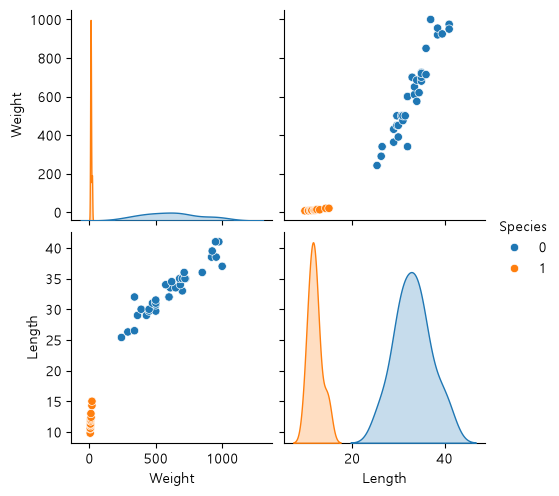

In [33]:
sns.pairplot(fish_df, hue="Species")
plt.show()

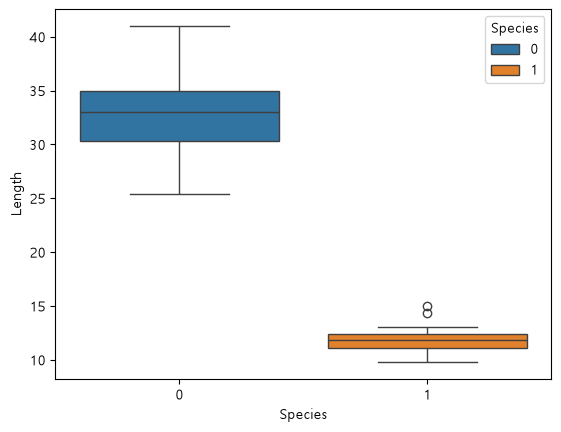

In [35]:
sns.boxplot(fish_df, y="Length", x="Species", hue="Species")
plt.show()

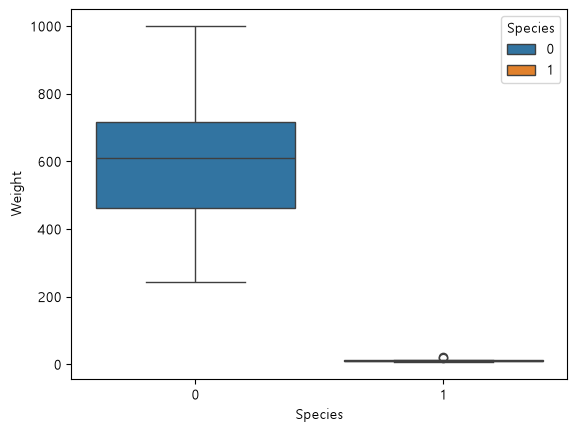

In [36]:
sns.boxplot(fish_df, y="Weight", x="Species", hue="Species")
plt.show()

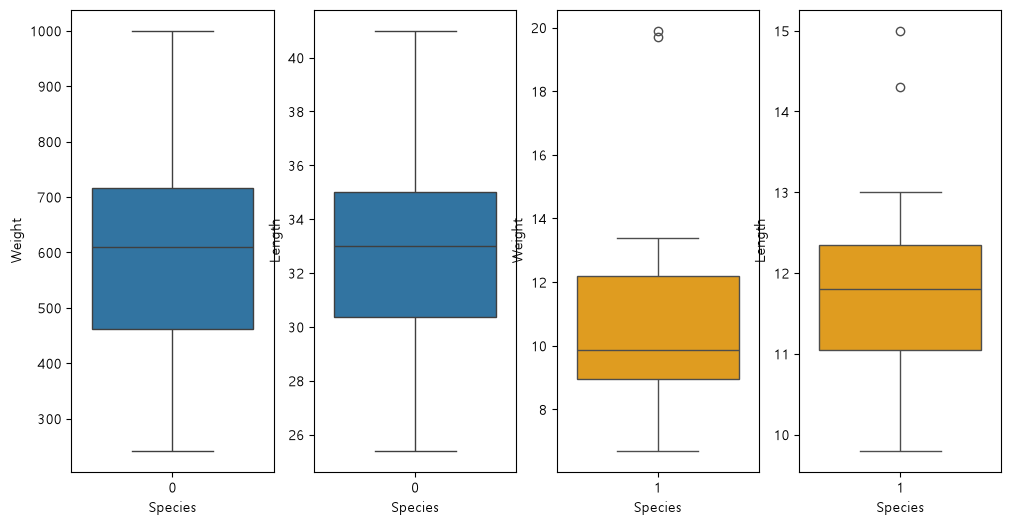

In [37]:
pig, axes = plt.subplots(1, 4, figsize=(12,6))
sns.boxplot(fish_df[fish_df["Species"] == 0], y="Weight", x="Species", ax=axes[0])
sns.boxplot(fish_df[fish_df["Species"] == 0], y="Length", x="Species", ax=axes[1])
sns.boxplot(fish_df[fish_df["Species"] == 1], y="Weight", x="Species", ax=axes[2], color="orange")
sns.boxplot(fish_df[fish_df["Species"] == 1], y="Length", x="Species", ax=axes[3], color="orange")
plt.show()

## 2단계. 데이터 분할

In [39]:
# 독립변수들(Weight, Length), 종속변수(Species)
X = fish_df.drop("Species",axis=1)
X.head()

,Weight,Length
0,242.0,25.4
1,290.0,26.3
2,340.0,26.5
3,363.0,29.0
4,430.0,29.0


In [41]:
y = fish_df["Species"]
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Species, dtype: int64

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2026)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(39, 2) (10, 2) (39,) (10,)


## 3단계. 모델 준비

# KNN(k-최근접 이웃, K-Neighbors) 알고리즘
- 어떤 데이터에 대한 답을 구할 때 주변의 다른 데이터를 보고 다수를 차지하는 데이터를 정답으로 결정하는 방식의 알고리즘.

## KNN 장점
- 데이터만 있으면 알고리즘을 사용할 수 있다.

## KNN 단점
- 데이터가 많으면 사용하기 힘들며, 많은 메모리를 사용한다.

In [46]:
from sklearn.neighbors import KNeighborsClassifier
# n_neighbors = 하이퍼 파라미터(최근접이웃) 개수
kn = KNeighborsClassifier()
KNeighborsClassifier?

Init signature:
KNeighborsClassifier(
    n_neighbors=5,
    *,
    weights='uniform',
    algorithm='auto',
    leaf_size=30,
    p=2,
    metric='minkowski',
    metric_params=None,
    n_jobs=None,
)
Docstring:     
Classifier implementing the k-nearest neighbors vote.

Read more in the :ref:`User Guide <classification>`.

Parameters
----------
n_neighbors : int, default=5
    Number of neighbors to use by default for :meth:`kneighbors` queries.

weights : {'uniform', 'distance'}, callable or None, default='uniform'
    Weight function used in prediction.  Possible values:

    - 'uniform' : uniform weights.  All points in each neighborhood
      are weighted equally.
    - 'distance' : weight points by the inverse of their distance.
      in this case, closer neighbors of a query point will have a
      greater influence than neighbors which are further away.
    - [callable] : a user-defined function which accepts an
      array of distances, and returns an array of the same shape

## 4단계. 모델 학습

In [47]:
# 표준화가 안된 쓰레기 데이터

In [50]:
kn.fit(X_train, y_train)

KNeighborsClassifier()

## 5단계. 모델 예측

In [53]:
y_pred = kn.predict(X_test)
print(y_pred)
print(list(y_test))

[0 1 0 0 0 0 0 1 1 0]
[0, 1, 0, 0, 0, 0, 0, 1, 1, 0]


## 6단계. 모델 평가

In [54]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [57]:
print(f"train 정답률 : {kn.score(X_train, y_train)}")
print(f"test 정답률 : {accuracy_score(y_test, y_pred)}")

train 정답률 : 1.0
test 정답률 : 1.0


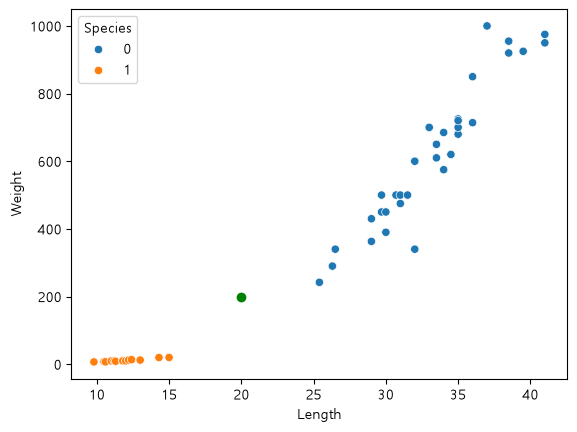

In [65]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="green")
plt.show()

In [66]:
columns = X_train.columns
new_data = pd.DataFrame([[20,200]], columns=columns)
new_data

,Weight,Length
0,20,200


In [67]:
kn.predict(new_data)

array([1])

In [69]:
distance, indexes = kn.kneighbors(new_data)
kn.kneighbors(new_data)

(array([[185.00002703, 185.70024233, 187.1626031 , 187.71606218,
         188.47082002]]),
 array([[32, 35, 10,  6,  4]]))

In [71]:
neighbors = X_train.iloc[indexes[0]]

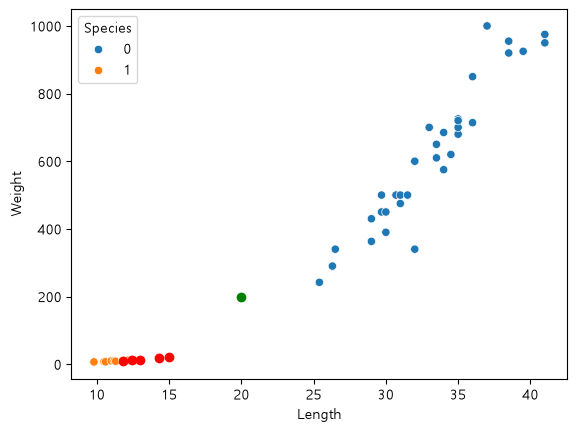

In [75]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.show()
# 그림만 보면 1보다 0에 더 가까워 보임. 그러나 x축의 수는 10~40인 반면 y축의 수는 0~1000이기 때문에 보이는 길이와 실제 길이가 다름 -> 정상적인 판단 안됨.

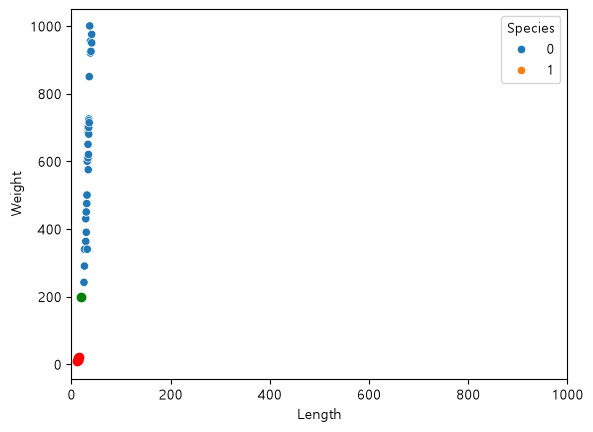

In [73]:
sns.scatterplot(fish_df, x="Length", y="Weight", hue="Species")
plt.scatter(20, 200, color="green")
plt.scatter(neighbors["Length"], neighbors["Weight"], color="red")
plt.xlim(0,1000)
plt.show()

In [77]:
# StandardScaler 표준화
from sklearn.preprocessing import StandardScaler

# (데이터 값 - 평균) / 표준편차
scaler = StandardScaler()

In [84]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [88]:
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
print(mean)
print(std)

Weight    453.935897
Length     27.158974
dtype: float64
Weight    327.314297
Length     10.150122
dtype: float64


In [90]:
X_train_scaled_df= (X_train - mean) / std
X_train_scaled_df["Species"] = y_train
X_train_scaled_df.head()

,Weight,Length,Species
32,1.439180,1.215850,0
17,0.751767,0.575464,0
145,-1.366381,-1.710223,1
21,0.705940,0.673985,0
152,-1.356604,-1.513181,1


In [93]:
new_data_scaled = (new_data - mean) / std
new_data_scaled

,Weight,Length
0,-1.325747,17.028467


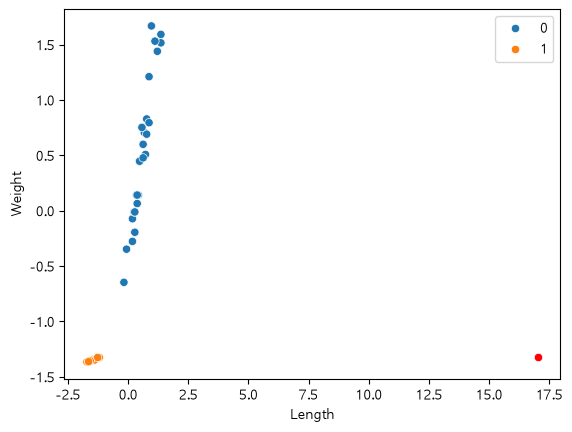

In [95]:
sns.scatterplot(X_train_scaled_df, x="Length", y="Weight", hue="Species")
sns.scatterplot(new_data_scaled, x="Length", y="Weight", color="red")
plt.show()

## 사이킷런 모델학습 사이클

In [100]:
# 모델 준비
kn = KNeighborsClassifier()

In [101]:
# 모델 학습
kn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [102]:
# 모델 예측
y_pred = kn.predict(X_test_scaled)
y_pred

array([0, 1, 0, 0, 0, 0, 0, 1, 1, 0])

In [103]:
        # 모델 평가
accuracy_score(y_pred,y_test)

1.0

In [111]:
# 혼동행렬
cm = confusion_matrix(y_test, y_pred)
cm

array([[7, 0],
       [0, 3]])

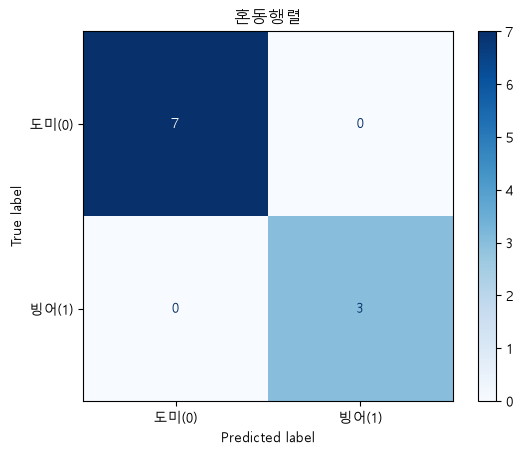

In [112]:
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["도미(0)","빙어(1)"])
display.plot(cmap="Blues")
plt.title("혼동행렬")
plt.show()